# 02 — Métricas de textura

O espectro de potência é estatística de **segunda ordem**: é matematicamente
equivalente à autocorrelação e **descarta a fase**. Duas imagens com espectro
idêntico podem ter organização espacial completamente diferente. Toda métrica aqui
entra por medir algo que a fase carrega e o espectro joga fora.

| família | mede | por que entra |
|---|---|---|
| gradiente / Laplaciano / Tenengrad | distribuição de |∇I| por pixel | detecção direta e barata de suavização e de ruído injetado |
| GLCM (Haralick) | distribuição conjunta de intensidades vizinhas | sensível à *forma* da coocorrência, não só à variância por frequência |
| LBP | microtextura por padrão binário local | pega o aspecto "plástico" na escala onde o espectro tem poucos bins |
| lacunaridade | heterogeneidade dos vazios por escala | a propriedade que β explicitamente **não** captura |
| top-hat | preservação de objetos pequenos e brilhantes | **estrutural, não textura** — é o achado clínico |
| SSIM / PSNR | fidelidade estrutural pareada | referência, **não** evidência de textura (premiam borrão) |

## Duas armadilhas resolvidas antes de medir

**Quantização da GLCM.** Se cada imagem for quantizada pelo próprio min/max, uma
diferença de faixa dinâmica vira "textura" que não é textura. Os bins são **globais
e fixos**, derivados dos percentis 1–99 do conjunto real, gravados no sidecar.

**Grade de intensidade.** O real é 12 bits e o sintético é float contínuo. Sem
alinhamento afim e requantização (feitos no notebook 00), LBP e gradiente separariam
os conjuntos pela estrutura de empates. Todas as métricas aqui operam sobre os
conjuntos já normalizados.

Toda métrica é calculada também na versão **passa-baixa** (`_lp`, λ > 8 px), onde o
artefato de 2 px do decodificador não alcança. É a única banda em que a pergunta
"a textura de tecido é consistente?" pode ser respondida.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

from texture import pipeline, stats as tstats  # noqa: E402
from texture.store import Config, metrics_wide  # noqa: E402

cfg = Config(ROOT / "config.yaml")

Extração completa (~20 min para 225 pares × 14 conjuntos). Idempotente por
`config_hash`.

In [2]:
pipeline.run_metrics(cfg)

/Users/bringel/ARIA/UPenn/avaliacao-de-mamografias-sinteticas/.venv/lib/python3.12/site-packages/skimage/feature/texture.py:385: UserWarning: Applying `local_binary_pattern` to floating-point images may give unexpected results when small numerical differences between adjacent pixels are present. It is recommended to use this function with images of integer dtype.
  warnings.warn(


  10/225 pares


  20/225 pares


  30/225 pares


  40/225 pares


...

  190/225 pares


  200/225 pares


  210/225 pares


  220/225 pares



550350 escalares de textura gravados


In [3]:
man = pd.read_csv(cfg.out / "manifest.csv")
mets = pd.read_parquet(cfg.out / "metrics.parquet")
wide = metrics_wide(mets)
print(f"{wide.shape[1]} métricas × {wide.index.get_level_values('pair_id').nunique()} pares "
      f"× {wide.index.get_level_values('set').nunique()} conjuntos")

191 métricas × 225 pares × 14 conjuntos


## 1. Sanidade: os controles se comportam como o esperado?

Antes de olhar o sintético. Se `bicubic_4` não tiver gradiente menor que o real, ou
`real_noise` não tiver gradiente maior, alguma coisa está errada no pipeline e
nenhum resultado sobre o modelo vale.

In [4]:
check_sets = ["real", "bicubic_2", "bicubic_4", "real_noise", "syn"]
check = pd.DataFrame({s: wide.xs(s, level="set")[
    ["grad_median", "laplacian_var", "glcm_contrast_d1_angmean", "lacunarity_8px"]].median()
    for s in check_sets if s in wide.index.get_level_values("set")}).T.round(5)
print(check.to_string())
assert check.loc["bicubic_4", "grad_median"] < check.loc["real", "grad_median"], \
    "o controle de suavização deveria ter gradiente menor que o real"
assert check.loc["real_noise", "grad_median"] > check.loc["real", "grad_median"], \
    "o controle de ruído deveria ter gradiente maior que o real"
print("\ncontroles se comportam na direção esperada")

metric      grad_median  laplacian_var  glcm_contrast_d1_angmean  lacunarity_8px
real            0.04989        0.00065                   0.33438         1.11585
bicubic_2       0.03803        0.00006                   0.17735         1.13576
bicubic_4       0.01955        0.00000                   0.08201         1.15899
real_noise      0.07207        0.00379                   0.78234         1.09379
syn             0.07256        0.00101                   0.49361         1.03324

controles se comportam na direção esperada


## 2. Onde cada família de métricas coloca o sintético

Cada painel: distribuição da métrica em cada conjunto. O que interessa é **onde o
sintético cai em relação aos controles** — se cai fora do intervalo real-vs-controles,
a métrica está vendo algo que nenhuma degradação simples reproduz.

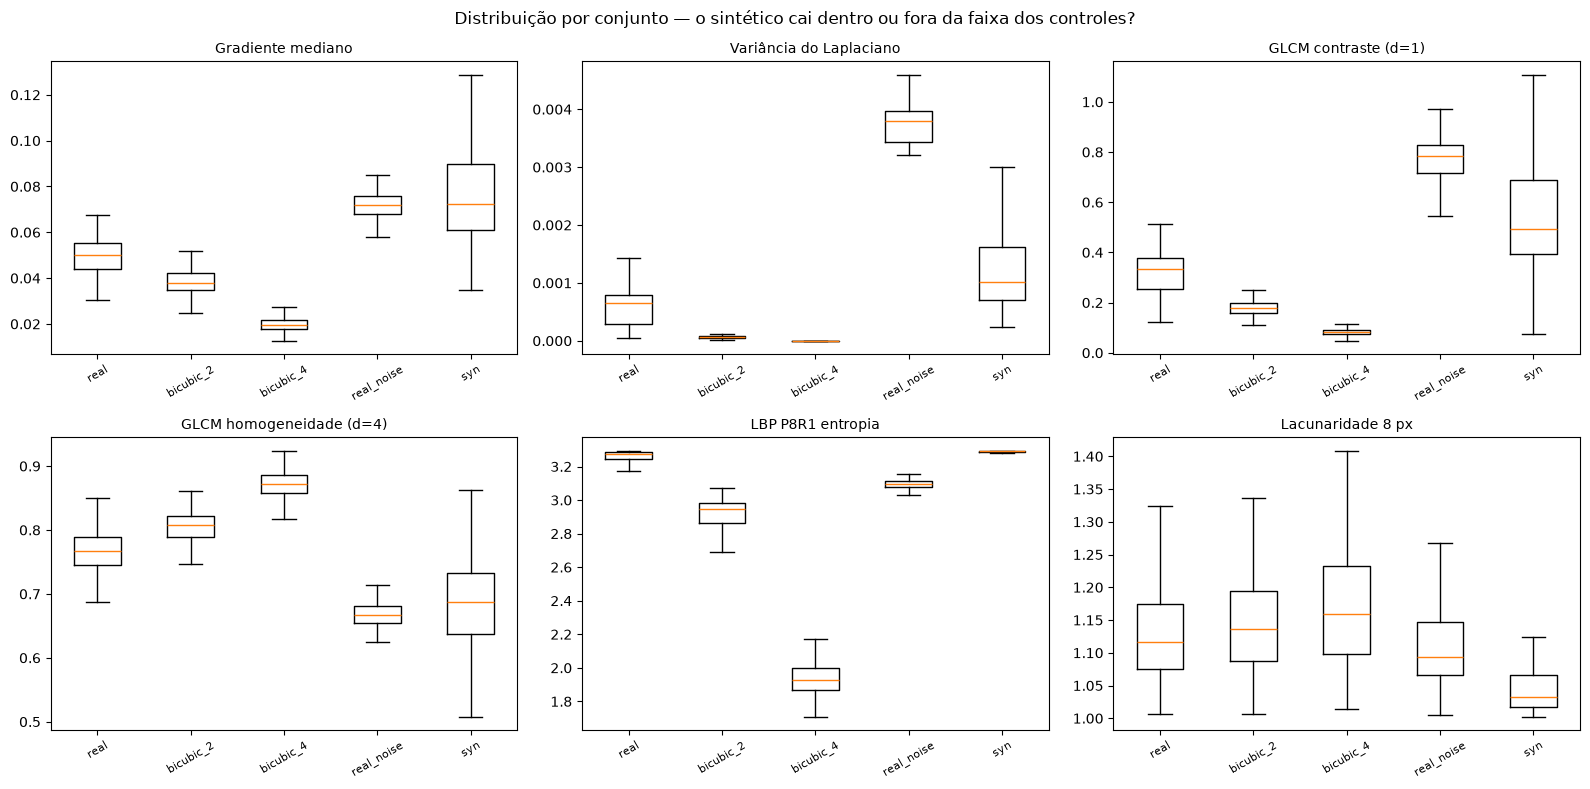

In [5]:
families = {
    "Gradiente mediano": "grad_median",
    "Variância do Laplaciano": "laplacian_var",
    "GLCM contraste (d=1)": "glcm_contrast_d1_angmean",
    "GLCM homogeneidade (d=4)": "glcm_homogeneity_d4_angmean",
    "LBP P8R1 entropia": "lbp_P8R1_entropy",
    "Lacunaridade 8 px": "lacunarity_8px",
}
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, (title, col) in zip(axes.ravel(), families.items()):
    data, labels = [], []
    for s in check_sets:
        if s in wide.index.get_level_values("set"):
            data.append(wide.xs(s, level="set")[col].dropna())
            labels.append(s)
    ax.boxplot(data, tick_labels=labels, showfliers=False)
    ax.set_title(title, fontsize=10)
    ax.tick_params(axis="x", rotation=30, labelsize=8)
fig.suptitle("Distribuição por conjunto — o sintético cai dentro ou fora da faixa dos controles?")
fig.tight_layout()

## 3. O efeito do passa-baixa

À esquerda, a métrica na imagem inteira; à direita, só a banda λ > 8 px. Se a
separação real↔sintético **desaparece** no passa-baixa, ela vinha do artefato de
escala fina, não da textura de tecido.

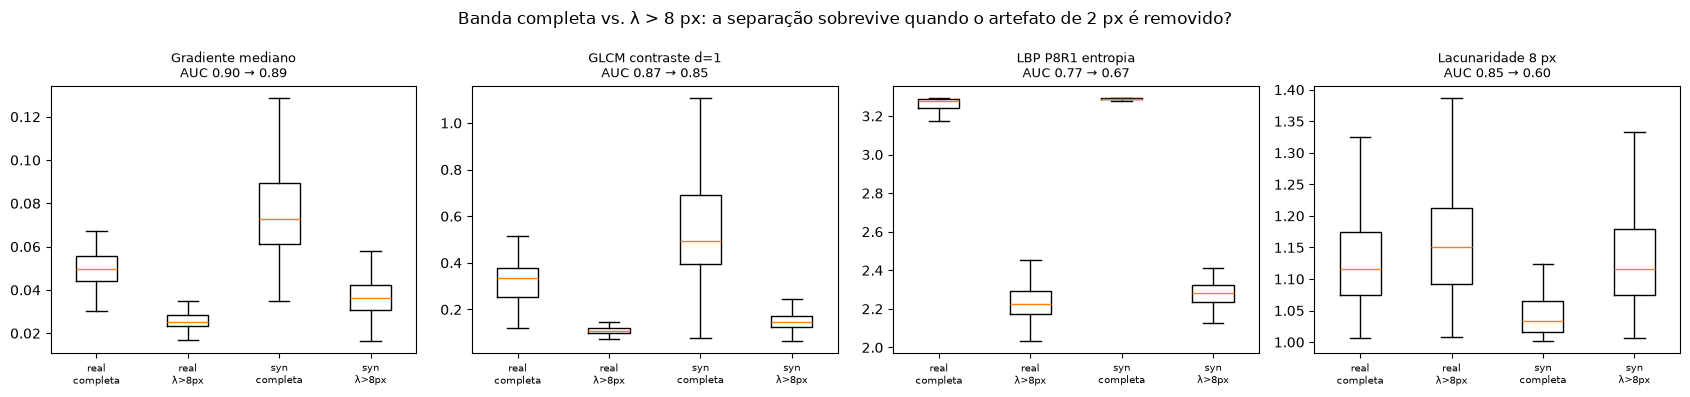

In [6]:
lp_pairs = [("grad_median", "Gradiente mediano"), ("glcm_contrast_d1_angmean", "GLCM contraste d=1"),
            ("lbp_P8R1_entropy", "LBP P8R1 entropia"), ("lacunarity_8px", "Lacunaridade 8 px")]
fig, axes = plt.subplots(1, 4, figsize=(17, 4))
for ax, (col, title) in zip(axes, lp_pairs):
    rows = []
    for base in ["real", "syn"]:
        for suffix, band in [("", "completa"), ("_lp", "λ>8px")]:
            s = base + suffix
            if s in wide.index.get_level_values("set"):
                rows.append((f"{base}\n{band}", wide.xs(s, level="set")[col].dropna()))
    ax.boxplot([r[1] for r in rows], tick_labels=[r[0] for r in rows], showfliers=False)
    auc_full = tstats.auc_mannwhitney(wide.xs("real", level="set")[col],
                                      wide.xs("syn", level="set")[col])
    auc_lp = tstats.auc_mannwhitney(wide.xs("real_lp", level="set")[col],
                                    wide.xs("syn_lp", level="set")[col])
    ax.set_title(f"{title}\nAUC {auc_full:.2f} → {auc_lp:.2f}", fontsize=9)
    ax.tick_params(axis="x", labelsize=7)
fig.suptitle("Banda completa vs. λ > 8 px: a separação sobrevive quando o artefato de 2 px é removido?")
fig.tight_layout()

## 4. Preservação de microcalcificações — estrutural, não textura

`tophat_recall_vs_real` é a fração dos objetos pequenos e brilhantes do real que têm
correspondente no conjunto. **Não entra na tabela de textura**: mede anatomia, não
estatística de tecido. Está aqui porque é o achado clinicamente mais grave, e porque
a correlação de Pearson — dominada pelo gradiente de espessura — não o detecta.

           syn  bicubic_2  bicubic_4  real_noise
count  186.000    186.000    186.000     186.000
mean     0.243      0.646      0.117       0.974
std      0.351      0.316      0.229       0.125
min      0.000      0.000      0.000       0.000
25%      0.000      0.500      0.000       1.000
50%      0.000      0.667      0.000       1.000
75%      0.469      1.000      0.141       1.000
max      1.000      1.000      1.000       1.000


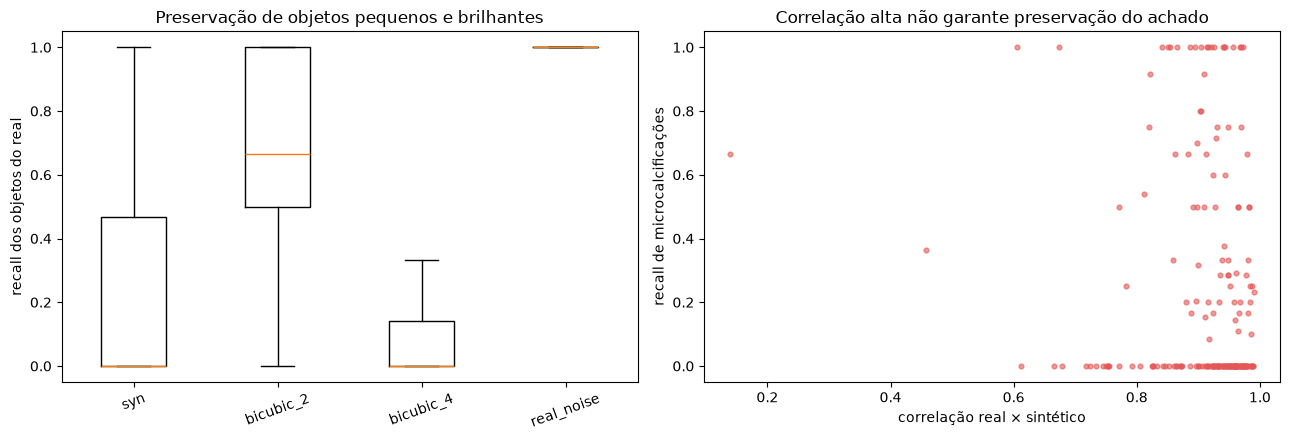

In [7]:
recall = {s: wide.xs(s, level="set")["tophat_recall_vs_real"].dropna()
          for s in ["syn", "bicubic_2", "bicubic_4", "real_noise"]
          if s in wide.index.get_level_values("set")}
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))
ax1.boxplot(list(recall.values()), tick_labels=list(recall), showfliers=False)
ax1.set(ylabel="recall dos objetos do real", title="Preservação de objetos pequenos e brilhantes")
ax1.tick_params(axis="x", rotation=20)
corr = pd.read_parquet(cfg.out / "qc.parquet").pivot_table(index="pair_id", columns="flag", values="value")["corr"]
r = recall["syn"]
ax2.scatter(corr.reindex(r.index), r, s=12, alpha=0.6, color="#E45756")
ax2.set(xlabel="correlação real × sintético", ylabel="recall de microcalcificações",
        title="Correlação alta não garante preservação do achado")
fig.tight_layout()
print(recall_summary := pd.DataFrame({k: v.describe() for k, v in recall.items()}).round(3).to_string())

## 5. SSIM / PSNR — com a ressalva no próprio gráfico

Em super-resolução, PSNR e SSIM **premiam borrão**: um modelo que devolve a média de
todas as texturas plausíveis maximiza PSNR e produz textura ruim. Se o bicúbico
vencer o difusor aqui, isso é o comportamento esperado — e precisa ser dito, não
escondido.

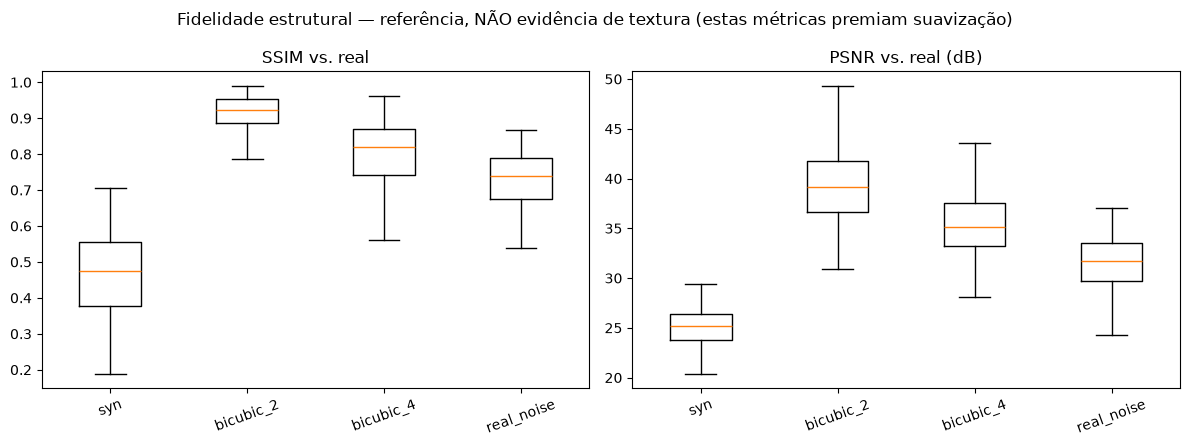

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, col, title in [(axes[0], "ssim_vs_real", "SSIM vs. real"), (axes[1], "psnr_vs_real", "PSNR vs. real (dB)")]:
    data, labels = [], []
    for s in ["syn", "bicubic_2", "bicubic_4", "real_noise"]:
        if s in wide.index.get_level_values("set"):
            v = wide.xs(s, level="set")[col].replace([np.inf, -np.inf], np.nan).dropna()
            data.append(v); labels.append(s)
    ax.boxplot(data, tick_labels=labels, showfliers=False)
    ax.set_title(title); ax.tick_params(axis="x", rotation=20)
fig.suptitle("Fidelidade estrutural — referência, NÃO evidência de textura "
             "(estas métricas premiam suavização)")
fig.tight_layout()